In [2]:
import sys
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "src" / "finetune").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print("project root:", ROOT)

import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from src.finetune import ensure_cyrillic, load_iam, TsvLineDataset, HFLineDataset

cfg = OmegaConf.load(ROOT / "configs" / "finetune.yaml")

project root: /workspace/HDD/handwriting-recognition/recognition


In [10]:
def show(dataset, n=6, title=""):
    n = min(n, len(dataset))
    if n == 0:
        print(f"{title}: empty"); return
    fig, axes = plt.subplots(n, 1, figsize=(12, 1.4 * n))
    axes = [axes] if n == 1 else axes
    for ax, i in zip(axes, range(n)):
        s = dataset[i]
        ax.imshow(s["image"]); ax.axis("off")
        ax.set_title(s["text"], fontsize=10, loc="left")
    fig.suptitle(title); plt.tight_layout(); plt.show()

def show_tsv(folder, glob, build_hint, title, subdir=""):
    tsv = next((ROOT / folder).glob(glob), None)
    if tsv is None:
        print(f"{title} not built -> {build_hint}")
        return
    ds = TsvLineDataset(tsv, tsv.parent, subdir)
    print(f"{title}: {len(ds)} lines (tsv: {tsv})")
    show(ds, title=title)

cyrillic train/test: 72284 1544


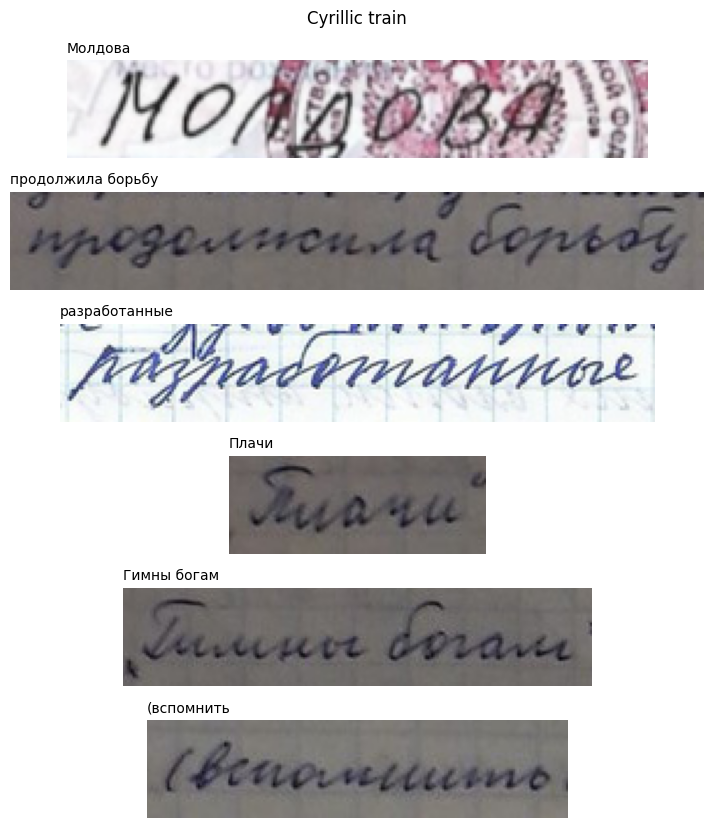

In [7]:
cyr_root = ROOT / cfg.data.sources.cyrillic.root
if next(cyr_root.glob("**/train.tsv"), None) is None:
    print(f"cyrillic not built -> python scripts/download/cyrillic.py --root {cfg.data.sources.cyrillic.root}")
else:
    cyr = ensure_cyrillic(cyr_root)
    cyr_train = TsvLineDataset(cyr.train_tsv, cyr.root, "train")
    cyr_test = TsvLineDataset(cyr.test_tsv, cyr.root, "test")
    print("cyrillic train/test:", len(cyr_train), len(cyr_test))
    show(cyr_train, title="Cyrillic train")

Generating train split:   0%|          | 0/6482 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/976 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2915 [00:00<?, ? examples/s]

iam train/test: 7458 2915


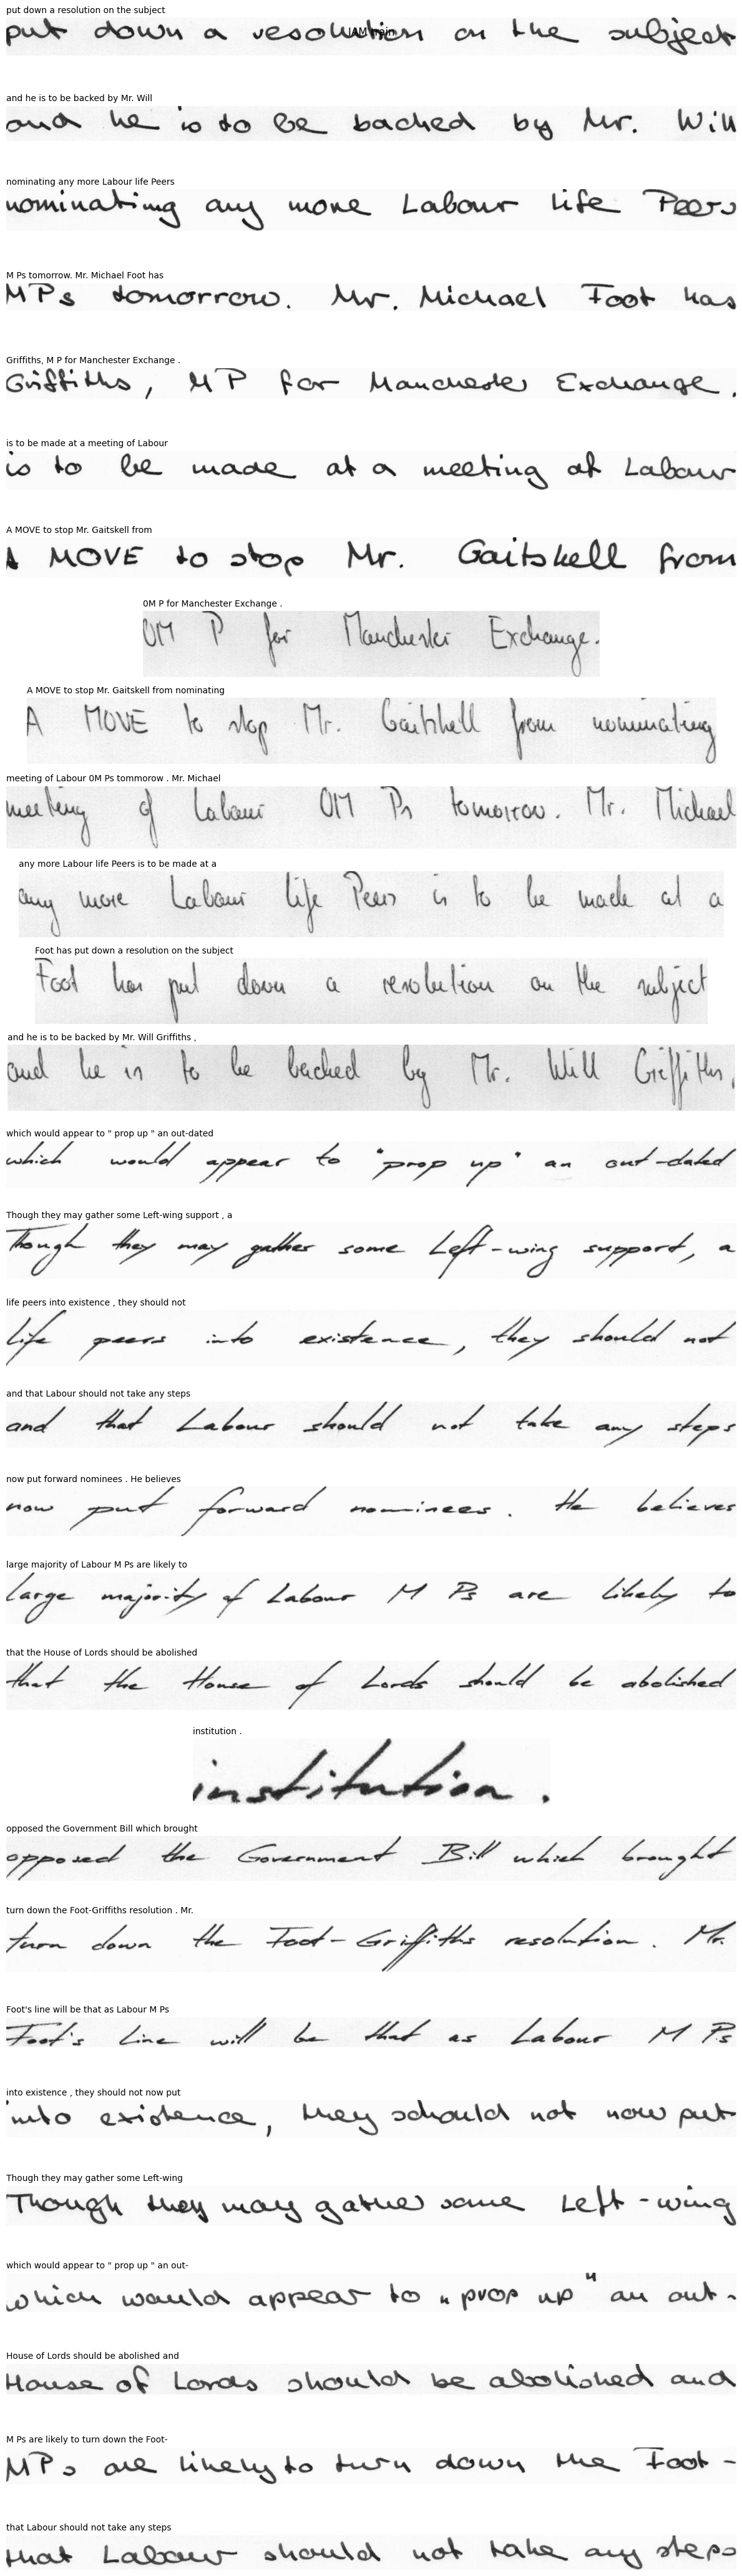

In [4]:
iam = load_iam(cfg.data.sources.get("iam"))
print("iam train/test:", len(iam.train) if iam else 0, len(iam.test) if iam and iam.test else 0)
if iam:
    show(HFLineDataset(iam.train, iam.image_key, iam.text_key), title="IAM train")

CVL (English): 13441 lines (tsv: /workspace/HDD/handwriting-recognition/recognition/data/cvl/cvl-database-1-1/cvl_train.tsv)


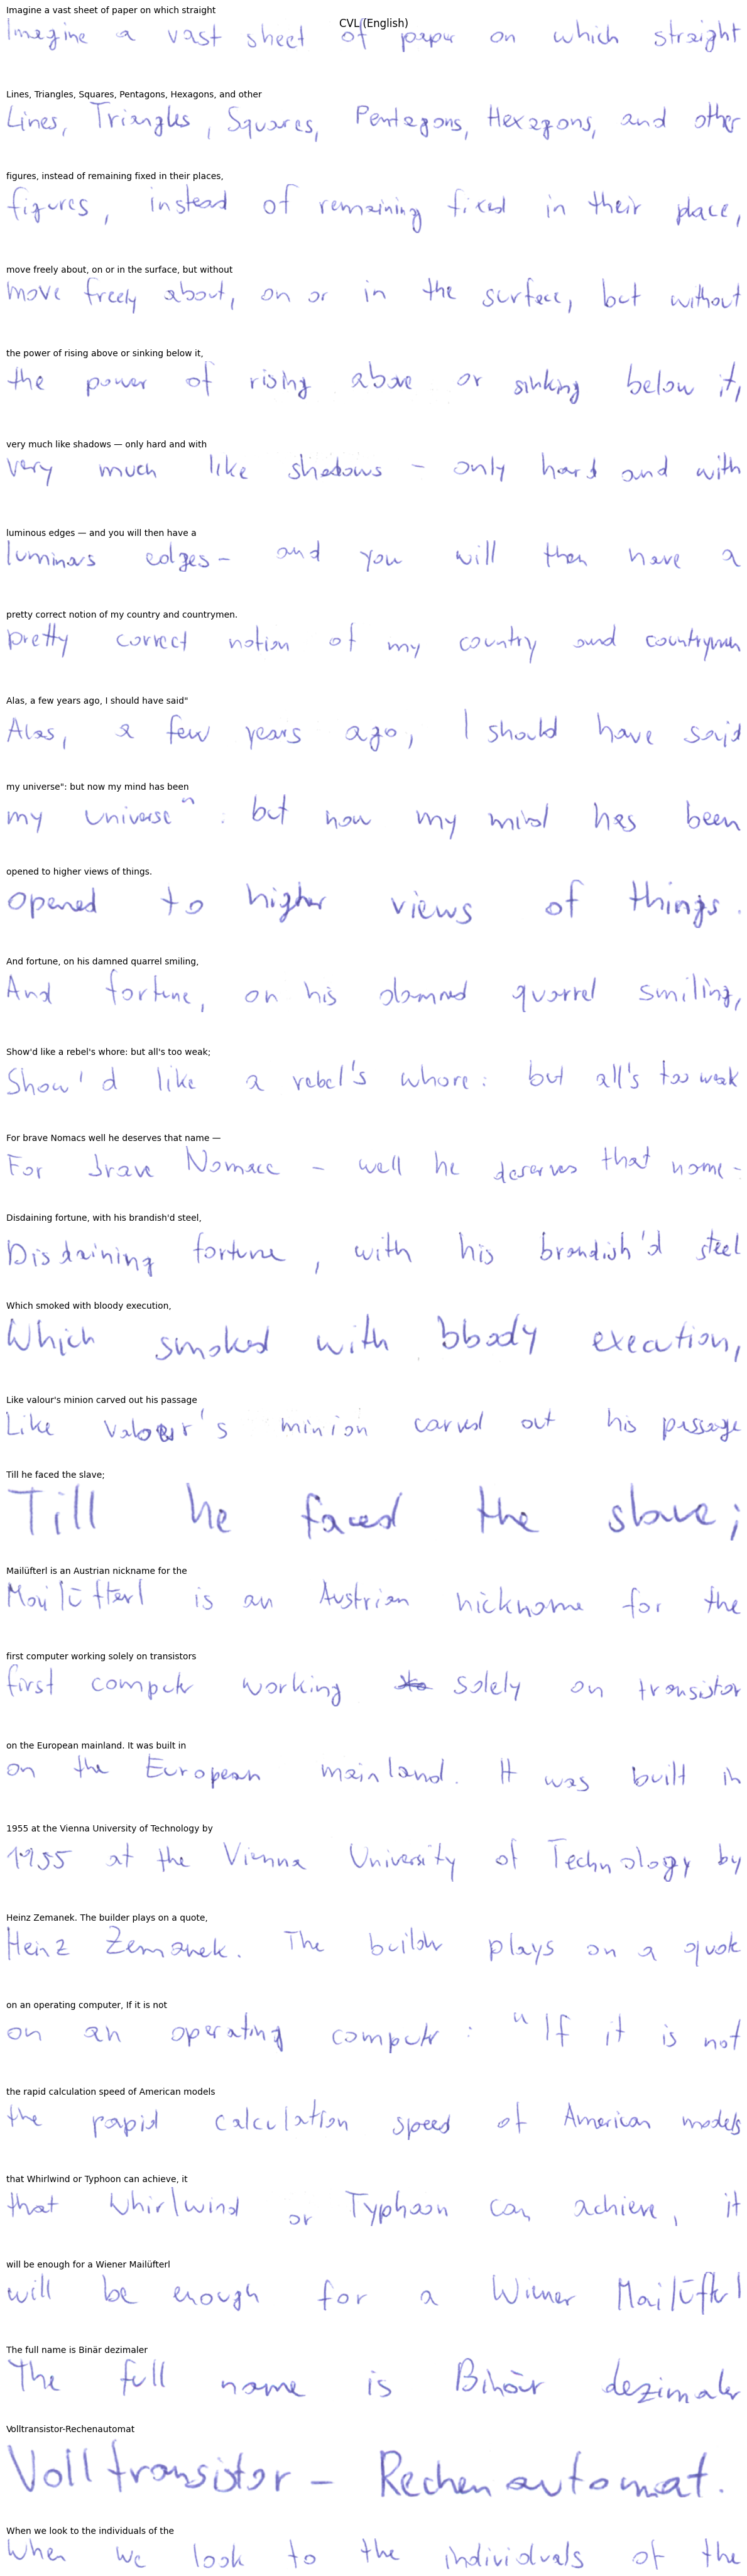

In [7]:
cvl = cfg.data.sources.cvl
show_tsv(cvl.root, cvl.train_glob, f"python scripts/download/cvl.py --root {cvl.root}", "CVL (English)")

IMGUR5K (English, words): 87005 lines (tsv: /workspace/HDD/handwriting-recognition/recognition/data/imgur5k/train_good_v2.tsv)


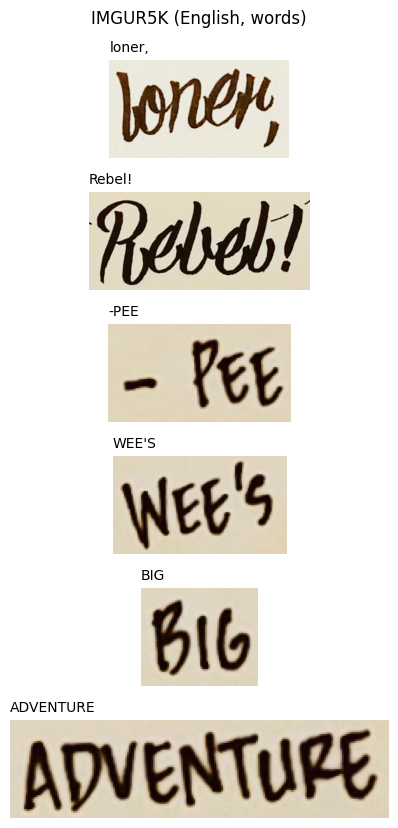

In [11]:
img5 = cfg.data.sources.imgur5k
show_tsv(img5.root, img5.train_glob,
         "python scripts/download/imgur5k.py --root <клон IMGUR5K> --out data/imgur5k",
         "IMGUR5K (English, words)")

it


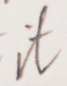

Call


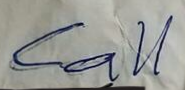

printing


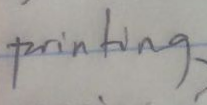

Travel


one


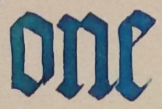

so


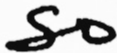

into


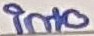

If


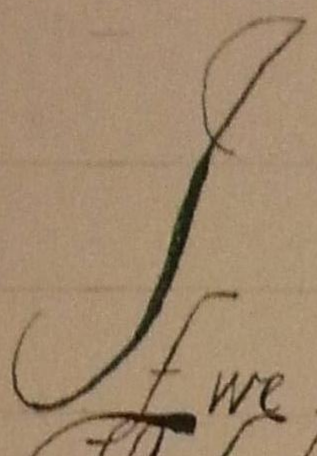

who


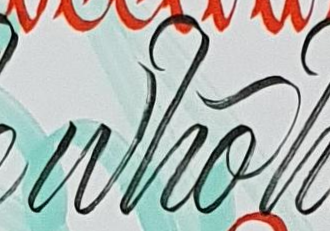

back


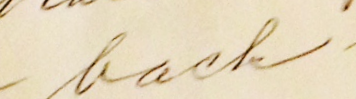

shall


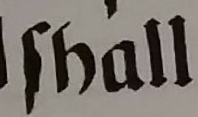

the


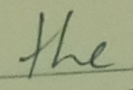

In [10]:
import random
from pathlib import Path
from PIL import Image

TSV, N = "../data/imgur5k/train_good.tsv", 12

rows = [ln.split("\t", 1) for ln in Path(TSV).read_text(encoding="utf-8").splitlines() if "\t" in ln]
for path, word in random.sample(rows, min(N, len(rows))):
    print(word)
    display(Image.open(path).convert("RGB"))

School Notebooks RU: 61889 lines (tsv: /workspace/HDD/handwriting-recognition/recognition/data/school_notebooks_ru/train.tsv)


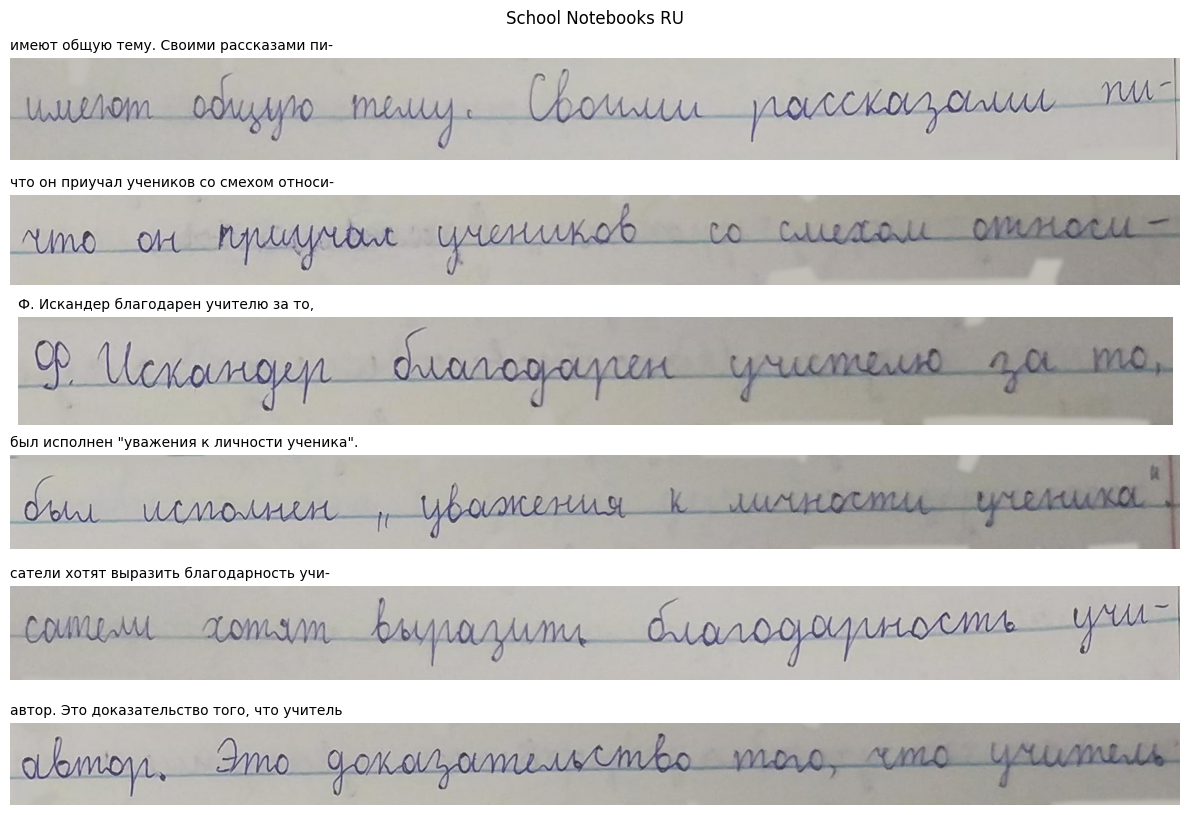

In [11]:
snr = cfg.data.sources.school_notebooks_ru
show_tsv(snr.root, snr.train_glob, "python scripts/download/all.py --datasets school_notebooks_ru", "School Notebooks RU")

School Notebooks EN: 2152 lines (tsv: /workspace/HDD/handwriting-recognition/recognition/data/school_notebooks_en/train.tsv)


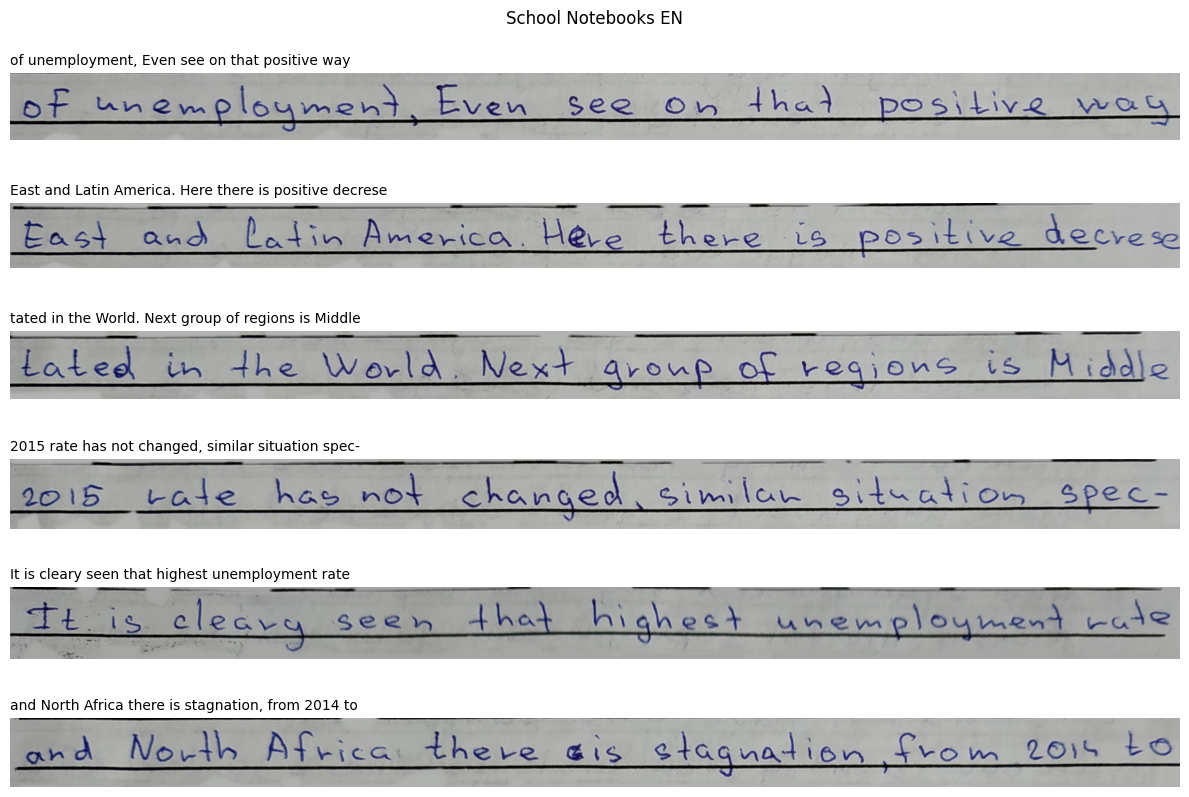

In [10]:
sne = cfg.data.sources.school_notebooks_en
show_tsv(sne.root, sne.train_glob, "python scripts/download/all.py --datasets school_notebooks_en", "School Notebooks EN")

In [3]:
print("lines per tsv:")
for name, s in cfg.data.sources.items():
    root = s.get("root")
    if not root:
        continue
    for tsv in sorted((ROOT / root).glob("**/*.tsv")):
        n = sum(1 for line in open(tsv, encoding="utf-8") if line.strip())
        print(f"  {tsv.relative_to(ROOT)}: {n}")

lines per tsv:
  data/cyrillic/test.tsv: 1544
  data/cyrillic/train.tsv: 72286
  data/school_notebooks_ru/test.tsv: 5470
  data/school_notebooks_ru/train.tsv: 61889
  data/cvl/cvl-database-1-1/cvl_train.tsv: 13441
  data/school_notebooks_en/test.tsv: 246
  data/school_notebooks_en/train.tsv: 2152
  data/imgur5k/test.tsv: 21819
  data/imgur5k/test_good.tsv: 13639
  data/imgur5k/train.tsv: 185008
  data/imgur5k/train_good.tsv: 115787
